In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

path = "/content/drive/MyDrive/"

matches = pd.read_csv(path + "Dataset1.csv")
deliveries = pd.read_csv(path + "IPL_Ball_by_Ball_2008_2022.csv")

print(matches.shape)
print(deliveries.shape)

(950, 20)
(225954, 17)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

from scipy.stats import zscore, chi2_contingency

import os

sns.set_style("whitegrid")


In [13]:
print(matches.isnull().sum())

# Fill missing values
matches['WinningTeam'] = matches['WinningTeam'].fillna('No Result')

# Remove matches without result unko rkhne m fayda nhi h
matches = matches[matches['WinningTeam'] != 'No Result']

# Drop rows with missing columns
matches = matches.dropna(subset=['Team1', 'Team2', 'TossWinner', 'TossDecision', 'Venue'])

# Reset index
matches.reset_index(drop=True, inplace=True)

print("Final shape:", matches.shape)

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            0
WinningTeam          0
WonBy                0
Margin              14
method             927
Player_of_Match      0
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64
Final shape: (946, 20)


In [14]:
matches['bat_first_team'] = matches.apply(
    lambda x: x['Team1'] if x['TossDecision'] == 'bat' else x['Team2'], axis=1)

matches['bat_first_won'] = (matches['WinningTeam'] == matches['bat_first_team']).astype(int)

matches[['Team1','Team2','TossDecision','WinningTeam','bat_first_team','bat_first_won']].head()

,Team1,Team2,TossDecision,WinningTeam,bat_first_team,bat_first_won
0,Rajasthan Royals,Gujarat Titans,bat,Gujarat Titans,Rajasthan Royals,0
1,Royal Challengers Bangalore,Rajasthan Royals,field,Rajasthan Royals,Rajasthan Royals,1
2,Royal Challengers Bangalore,Lucknow Super Giants,field,Royal Challengers Bangalore,Lucknow Super Giants,0
3,Rajasthan Royals,Gujarat Titans,field,Gujarat Titans,Gujarat Titans,1
4,Sunrisers Hyderabad,Punjab Kings,bat,Punjab Kings,Sunrisers Hyderabad,0


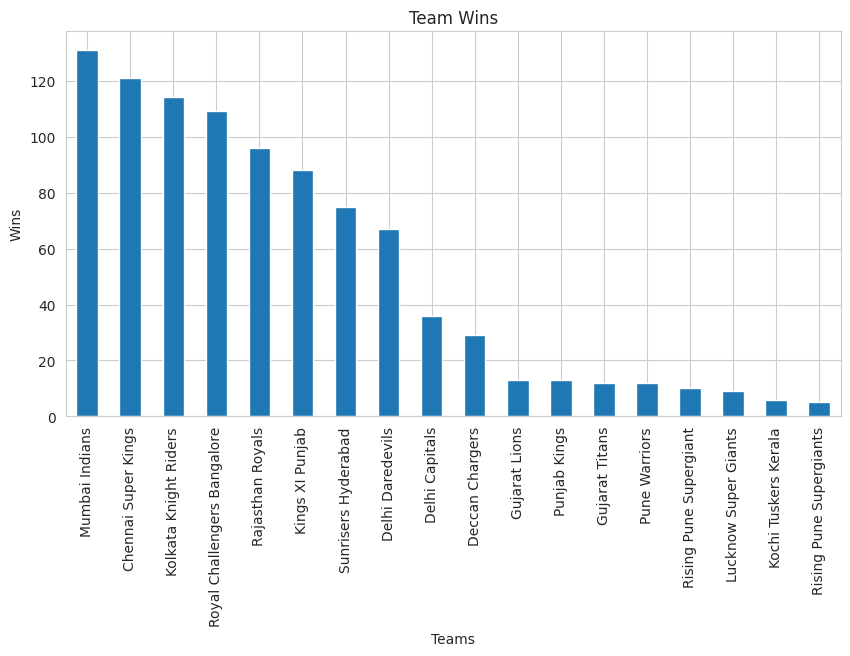

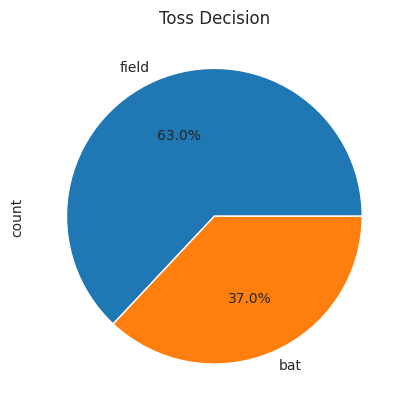

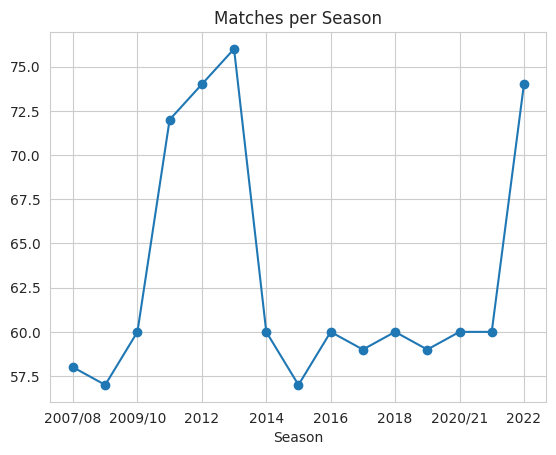

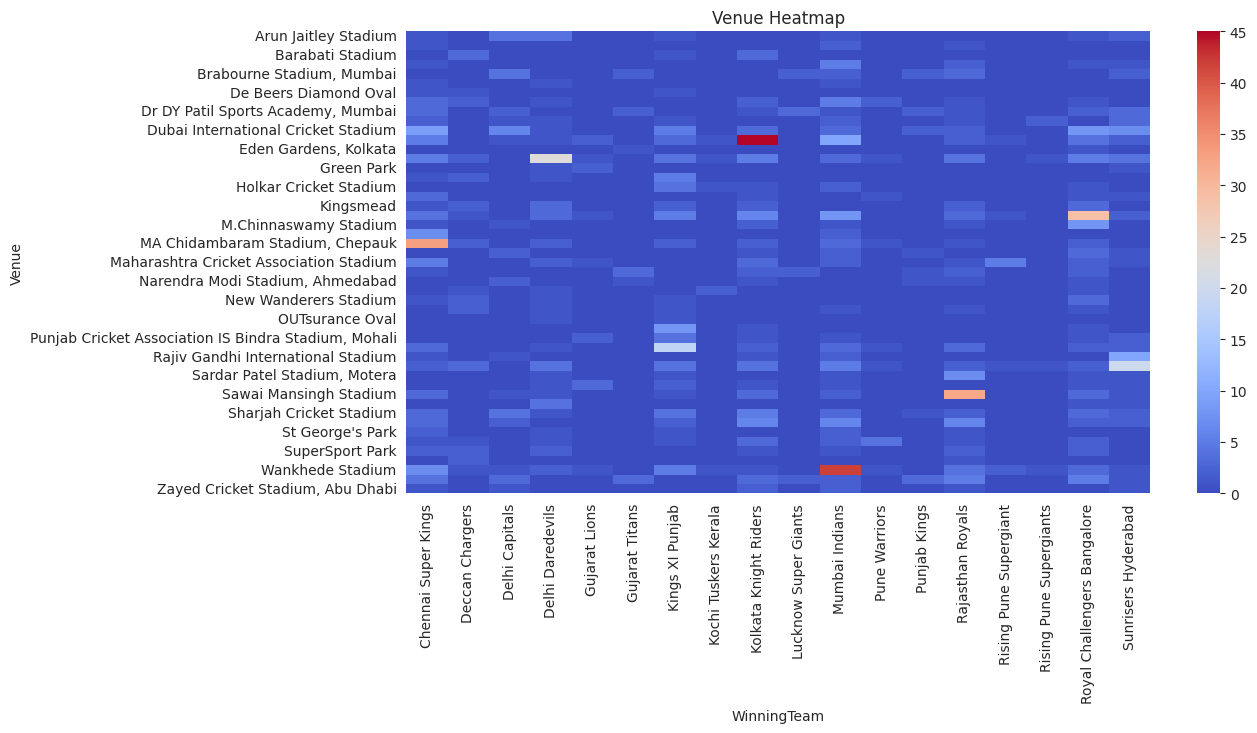

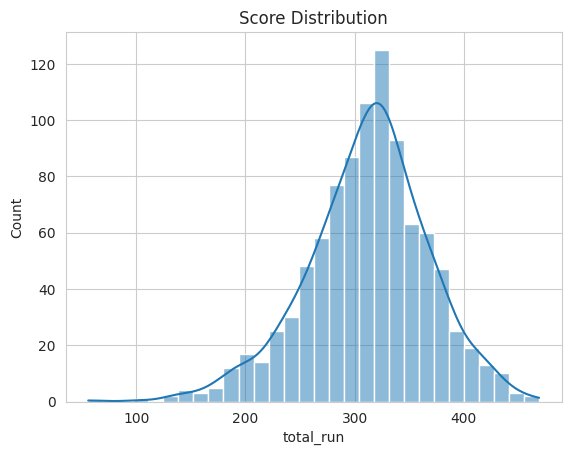

In [19]:

save_path = path + "outputs/"
import os
os.makedirs(save_path, exist_ok=True)

# Team Wins
plt.figure(figsize=(10,5))
matches['WinningTeam'].value_counts().plot(kind='bar')
plt.title("Team Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.savefig(save_path + "team wins.png", dpi=150)
plt.show()


# Toss Decision
plt.figure()
matches['TossDecision'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Toss Decision")
plt.savefig(save_path + "toss pie.png", dpi=150)
plt.show()


# Matches per Season
plt.figure()
matches['Season'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Matches per Season")
plt.savefig(save_path + "matches per season.png", dpi=150)
plt.show()


# Venue Heatmap
plt.figure(figsize=(12,6))
heatmap_data = pd.crosstab(matches['Venue'], matches['WinningTeam'])
sns.heatmap(heatmap_data, cmap="coolwarm")
plt.title("Venue Heatmap")
plt.savefig(save_path + "venue heatmap.png", dpi=150)
plt.show()


# Score Distribution
runs_per_match = deliveries.groupby('ID')['total_run'].sum()

plt.figure()
sns.histplot(runs_per_match, kde=True)
plt.title("Score Distribution")
plt.savefig(save_path + "score distribution.png", dpi=150)
plt.show()

IQR Outliers: 19
Z-score Outliers: 7


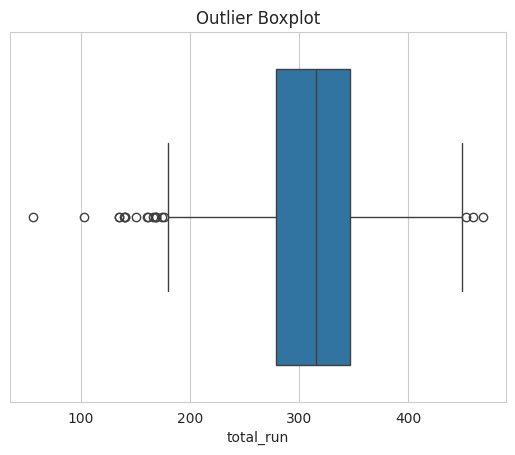

In [20]:
# finding outliers by IQR Method
Q1 = runs_per_match.quantile(0.25)
Q3 = runs_per_match.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = runs_per_match[(runs_per_match < lower) | (runs_per_match > upper)]
print("IQR Outliers:", len(iqr_outliers))


# Z-score Method
from scipy.stats import zscore
z_scores = zscore(runs_per_match)

z_outliers = runs_per_match[abs(z_scores) > 3]
print("Z-score Outliers:", len(z_outliers))


# Boxplot
plt.figure()
sns.boxplot(x=runs_per_match)
plt.title("Outlier Boxplot")
plt.savefig(save_path + "outlier boxplot.png", dpi=150)
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Team1', 'Team2', 'TossWinner', 'Venue']:
    matches[col] = le.fit_transform(matches[col].astype(str))


# Features & Target
X = matches[['Team1', 'Team2', 'TossWinner', 'Venue']]
y = matches['bat_first_won']


# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42)


# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")


Train Performance:
Accuracy: 0.5428907168037603
Precision: 0.551829268292683
Recall: 0.7921225382932167
F1 Score: 0.6504941599281222

Test Performance:
Accuracy: 0.49473684210526314
Precision: 0.5230769230769231
Recall: 0.6666666666666666
F1 Score: 0.5862068965517241


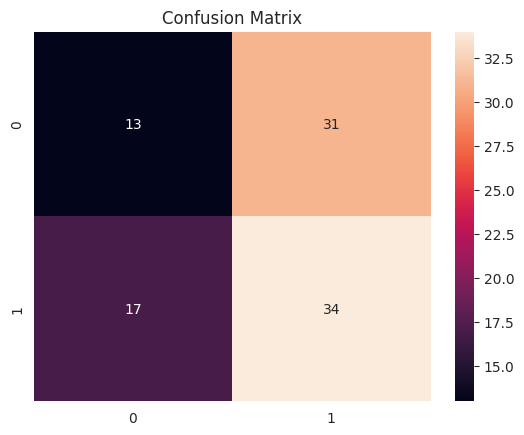

In [23]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig(save_path + "confusion matrix.png", dpi=150)
plt.show()

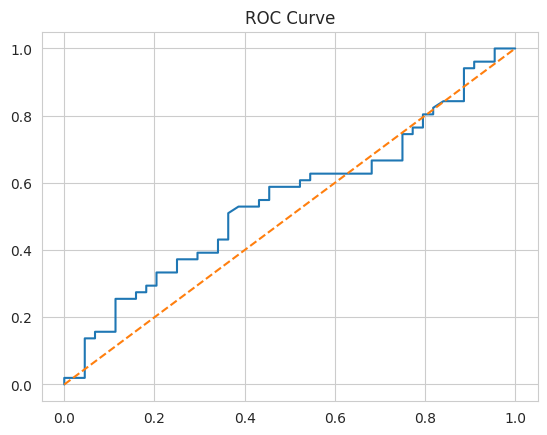

AUC Score: 0.5490196078431373


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.savefig(save_path + "roc curve.png", dpi=150)
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [25]:
# CHI-SQUARE TEST

from scipy.stats import chi2_contingency

contingency = pd.crosstab(matches['TossDecision'], matches['bat_first_won'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

if p < 0.05:
    print("Reject Null Hypothesis → Toss decision impacts match result")
else:
    print("Fail to Reject Null → No significant relation")

Chi2: 1.0399209075806544
Degrees of Freedom: 1
P-value: 0.3078398674246784
Fail to Reject Null → No significant relation


In [26]:
# SUMMARY

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ]
})

metrics

,Metric,Train,Test
0,Accuracy,0.542891,0.494737
1,Precision,0.551829,0.523077
2,Recall,0.792123,0.666667
3,F1 Score,0.650494,0.586207
